<a href="https://colab.research.google.com/github/ayush01792/AR-news/blob/main/House_predection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install XGBoost (not pre-installed in Colab)
!pip install xgboost -q

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn — data, preprocessing, models, evaluation
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Show all plots inline
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the dataset
housing = fetch_california_housing()

# Convert to DataFrame (like Excel table)
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add the target column (what we're predicting)
df['MedHouseVal'] = housing.target

# Basic exploration
print("Shape:", df.shape)           # rows × columns
print("\nFirst 5 rows:")
print(df.head())

print("\nData types and missing values:")
print(df.info())

print("\nStatistical summary:")
print(df.describe())

Shape: (20640, 9)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  

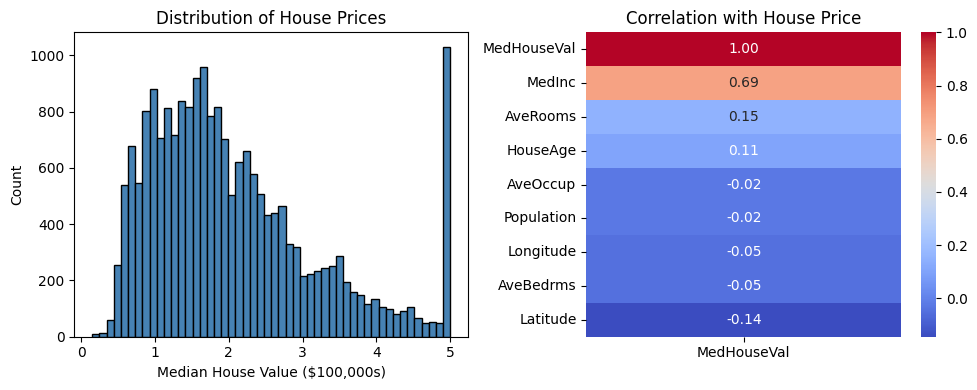


Top features correlated with price:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [3]:
# 1. Distribution of house prices
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of House Prices')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Count')

# 2. Correlation heatmap — which features relate to price?
plt.subplot(1, 2, 2)
corr = df.corr()
sns.heatmap(corr[['MedHouseVal']].sort_values('MedHouseVal', ascending=False),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation with House Price')

plt.tight_layout()
plt.show()

print("\nTop features correlated with price:")
print(corr['MedHouseVal'].sort_values(ascending=False))

In [4]:
# Feature engineering — create new meaningful features
df['rooms_per_person'] = df['AveRooms'] / df['AveOccup']
df['bedrooms_ratio'] = df['AveBedrms'] / df['AveRooms']

print("New features added. New shape:", df.shape)

# Separate features (X) and target (y)
X = df.drop('MedHouseVal', axis=1)  # everything except price
y = df['MedHouseVal']               # just the price

# Split into train (80%) and test (20%)
# random_state=42 means same split every time (reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

# Scale features — bring all features to same scale
# StandardScaler: mean=0, std=1 for each feature
scaler = StandardScaler()

# IMPORTANT: fit only on training data, then transform both
# If we fit on test data too, we'd be "leaking" test information
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # only transform, don't fit

print("\nScaling done. Sample of scaled features:")
print(X_train_scaled[:2])

New features added. New shape: (20640, 11)
Training set size: 16512 rows
Test set size: 4128 rows

Scaling done. Sample of scaled features:
[[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
  -1.3728112   1.27258656 -0.55201735 -0.2117846 ]
 [-0.03584338  1.61811813 -0.40283542 -0.12853018 -0.09890135 -0.11736222
  -0.87669601  0.70916212  0.5269557   0.34218528]]


In [5]:
# Define all models we want to compare
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

# Store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"Training {name}...")

    # Train
    model.fit(X_train_scaled, y_train)

    # Predict on test set
    y_pred = model.predict(X_test_scaled)

    # Evaluate
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'predictions': y_pred}

    print(f"  MAE:  {mae:.4f} (${mae*100000:,.0f} average error)")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f} ({r2*100:.1f}% variance explained)")
    print()

Training Linear Regression...
  MAE:  0.4862 ($48,616 average error)
  RMSE: 0.6753
  R²:   0.6519 (65.2% variance explained)

Training Decision Tree...
  MAE:  0.4343 ($43,433 average error)
  RMSE: 0.6464
  R²:   0.6811 (68.1% variance explained)

Training Random Forest...
  MAE:  0.3287 ($32,874 average error)
  RMSE: 0.5048
  R²:   0.8055 (80.6% variance explained)

Training XGBoost...
  MAE:  0.3047 ($30,467 average error)
  RMSE: 0.4592
  R²:   0.8391 (83.9% variance explained)



=== Model Comparison ===
                      MAE    RMSE      R2
Linear Regression  0.4862  0.6753  0.6519
Decision Tree      0.4343  0.6464  0.6811
Random Forest      0.3287  0.5048  0.8055
XGBoost            0.3047  0.4592  0.8391


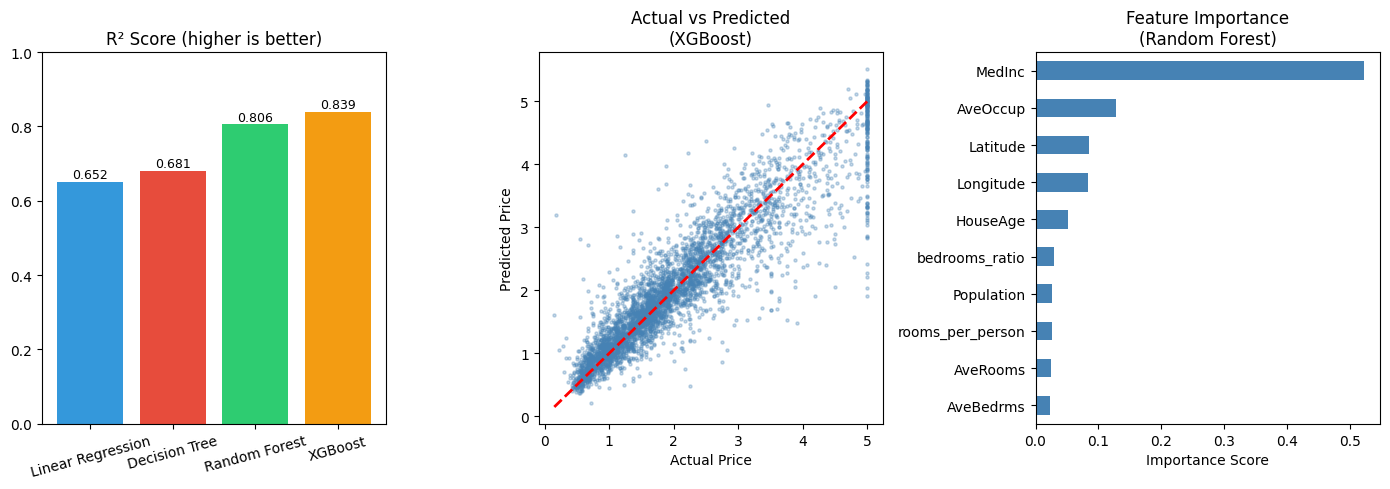


🏆 Best model: XGBoost with R² = 0.8391


In [6]:
# Results comparison table
results_df = pd.DataFrame({
    name: {'MAE': r['MAE'], 'RMSE': r['RMSE'], 'R2': r['R2']}
    for name, r in results.items()
}).T

print("=== Model Comparison ===")
print(results_df.round(4))

# Plot 1 — R² comparison
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
r2_scores = [results[m]['R2'] for m in models]
plt.bar(models.keys(), r2_scores, color=['#3498db','#e74c3c','#2ecc71','#f39c12'])
plt.title('R² Score (higher is better)')
plt.xticks(rotation=15)
plt.ylim(0, 1)
for i, v in enumerate(r2_scores):
    plt.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9)

# Plot 2 — Actual vs Predicted (best model)
best_model = max(results, key=lambda x: results[x]['R2'])
y_pred_best = results[best_model]['predictions']

plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_best, alpha=0.3, color='steelblue', s=5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted\n({best_model})')

# Plot 3 — Feature importance (Random Forest)
plt.subplot(1, 3, 3)
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance\n(Random Forest)')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.show()

print(f"\n🏆 Best model: {best_model} with R² = {results[best_model]['R2']:.4f}")

In [7]:
# Predict price for a custom house
# Let's say: median income=5.0, house age=20, avg rooms=6,
# avg bedrooms=1.2, population=1000, avg occupancy=3,
# latitude=37.0, longitude=-120.0

custom_house = pd.DataFrame({
    'MedInc': [5.0],
    'HouseAge': [20.0],
    'AveRooms': [6.0],
    'AveBedrms': [1.2],
    'Population': [1000.0],
    'AveOccup': [3.0],
    'Latitude': [37.0],
    'Longitude': [-120.0],
    'rooms_per_person': [6.0/3.0],
    'bedrooms_ratio': [1.2/6.0]
})

# Scale using the same scaler we trained on
custom_scaled = scaler.transform(custom_house)

# Predict using best model
prediction = models[best_model].predict(custom_scaled)[0]
print(f"Predicted house price: ${prediction * 100000:,.0f}")

Predicted house price: $185,800
